# 조기 배송과 재구매율 — 기대 관리(Expectation)의 영향

## 분석 목적
앞선 노트북(`funnel_delay_1·2`)이 *"지연이 재구매를 떨어뜨리는가"* 를 봤다면,
여기서는 반대로 **"빨리 도착하면(조기 배송) 재구매가 올라가는가"** 를 확인한다.

특히 **약속(예정일) 대비 실제 배송**의 조합에 주목한다.

> 🎯 **핵심 질문** :
> **① 길게 잡고 빨리 배송** (예정일을 넉넉히 약속 → 그보다 일찍 도착, *under-promise / over-deliver*)
> vs
> **② 짧게 잡고 늦게 배송** (예정일을 빠듯하게 약속 → 그보다 늦게 도착, *over-promise / under-deliver*)
> — **두 전략 중 어느 쪽이 재구매로 더 잘 이어지는가?**

이는 단순 배송 속도가 아니라 **기대치 관리(expectation management)** 가
고객 충성도에 미치는 영향을 보는 분석이다.

## 분석 데이터
- `olist_order_item_level.csv` (본 노트북과 같은 폴더) — 모든 경로는 **상대 경로** 사용

## 핵심 변수 정의
| 변수 | 정의 | 의미 |
|------|------|------|
| `promised_days` | 예정 도착일 − 구매일 | **약속한** 배송 기간 (길게/짧게 잡았는가) |
| `actual_days` | 실제 도착일 − 구매일 | **실제** 걸린 배송 기간 |
| `late_days` | 실제 도착일 − 예정 도착일 | 음수=조기(빨리), 양수=지연(늦게) |

재구매는 앞 노트북과 동일하게 **첫 주문 기준**(편향 통제)으로 측정한다.


## 0. 환경 설정 및 시각화 서식 통일

`funnel_delay_1·2` 와 동일한 서식을 사용한다. 추가로 **배송 속도(조기/지연)** 색상을 정의한다.
- `SPEED_PALETTE` : 빨리(조기)=초록, 늦게(지연)=빨강


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import matplotlib.font_manager as fm

# 한글 폰트 - Windows/Jupyter
font_path = r"C:\Windows\Fonts\malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])

# ── 시각화 공통 서식 (앞 노트북과 통일) ──────────────────────────
FIGSIZE = (8, 5)
TITLE_FS, LABEL_FS = 14, 12

# 배송 속도: 빨리(조기)=초록(긍정) / 늦게(지연)=빨강(부정)
SPEED_PALETTE = {"빨리(조기 배송)": "#2E7D5B", "늦게(지연 배송)": "#C0392B"}
SPEED_ORDER   = ["빨리(조기 배송)", "늦게(지연 배송)"]

def annotate_bars(ax, fmt="{:.1%}", fontsize=12):
    """막대 위에 값 라벨을 통일된 형식으로 표기."""
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h) and h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom",
                        fontsize=fontsize, fontweight="bold")

print("✅ 환경 설정 완료 / 폰트:", plt.rcParams["font.family"])

✅ 환경 설정 완료 / 폰트: ['Malgun Gothic']


## 1. 데이터 불러오기 & 핵심 변수 만들기

앞 노트북과 동일한 정제 규칙(주문 단위 · 배송완료 · 정상 주문) 위에
약속/실제 배송 기간과 조기·지연 변수를 계산한다.


In [2]:
# 상대 경로 사용
DATA_PATH = "olist_order_item_level.csv"
raw = pd.read_csv(DATA_PATH)
print(f"원본 shape : {raw.shape[0]:,} 행 × {raw.shape[1]} 열")

# 주문 단위 + 배송완료 + 정상 주문
o = raw.drop_duplicates(subset="order_id").copy()
o = o[o["is_delivered"].eq(True) & o["anomaly_flag"].eq(0)].copy()

# 날짜 파싱
purchase  = pd.to_datetime(o["order_purchase_timestamp"], errors="coerce")
estimated = pd.to_datetime(o["order_estimated_delivery_date"], errors="coerce")
delivered = pd.to_datetime(o["order_delivered_customer_date"], errors="coerce")

# 핵심 변수
o["purchase_ts"]   = purchase
o["promised_days"] = (estimated - purchase).dt.total_seconds() / 86400   # 약속 기간
o["actual_days"]   = (delivered - purchase).dt.total_seconds() / 86400   # 실제 기간
o["late_days"]     = (delivered - estimated).dt.total_seconds() / 86400  # 음수=조기, 양수=지연
o["early_days"]    = -o["late_days"]                                     # 양수=며칠 일찍 도착

# 결측 제거(날짜 파싱 실패분)
o = o.dropna(subset=["promised_days", "actual_days", "late_days"]).copy()

print(f"분석 주문 수 : {o['order_id'].nunique():,} 건")
print(f"조기 배송 비율(예정보다 일찍 도착) : {(o['late_days'] <= 0).mean():.1%}")
print(f"평균 약속 기간 : {o['promised_days'].mean():.1f}일 / 평균 실제 기간 : {o['actual_days'].mean():.1f}일")
o[["order_id", "promised_days", "actual_days", "late_days", "early_days"]].head()

원본 shape : 112,650 행 × 67 열
분석 주문 수 : 95,082 건
조기 배송 비율(예정보다 일찍 도착) : 91.8%
평균 약속 기간 : 23.7일 / 평균 실제 기간 : 12.6일


,order_id,promised_days,actual_days,late_days,early_days
0,00010242fe8c5a6d1ba2dd792cb16214,15.625671,7.614421,-8.011250,8.011250
1,00018f77f2f0320c557190d7a144bdd3,18.546458,16.216181,-2.330278,2.330278
2,000229ec398224ef6ca0657da4fc703e,21.393391,7.948437,-13.444954,13.444954
3,00024acbcdf0a6daa1e931b038114c75,11.582928,6.147269,-5.435660,5.435660
4,00042b26cf59d7ce69dfabb4e55b4fd9,40.418160,25.114352,-15.303808,15.303808


## 2. 첫 주문 기준 고객 테이블

고객별 **첫 주문**의 배송 특성과 재구매 여부를 정리한다.
첫 주문을 기준으로 하는 이유는 앞 노트북과 동일하다 — *주문이 많을수록 특정 배송 경험을 겪을
확률이 높아지는 편향*을 피하고, 모든 고객을 같은 출발선에서 비교하기 위해서다.


In [3]:
order_sorted = o.sort_values("purchase_ts").copy()
order_sorted["order_rank"] = order_sorted.groupby("customer_unique_id").cumcount()

# 고객별 총 주문 수 → 재구매 여부
n_orders = order_sorted.groupby("customer_unique_id")["order_id"].nunique()

# 첫 주문만 추출
cust = order_sorted[order_sorted["order_rank"] == 0].copy()
cust["repurchased"] = cust["customer_unique_id"].map(n_orders) > 1

print(f"전체(첫 주문) 고객 수 : {len(cust):,} 명")
print(f"전체 재구매율         : {cust['repurchased'].mean():.2%}")
cust[["customer_unique_id", "promised_days", "actual_days", "late_days", "early_days", "repurchased"]].head()

전체(첫 주문) 고객 수 : 92,025 명
전체 재구매율         : 2.98%


,customer_unique_id,promised_days,actual_days,late_days,early_days,repurchased
84389,830d5b7aaa3b6f1e9ad63703bec97d23,18.488449,54.813194,36.324745,-36.324745,False
26119,32ea3bdedab835c3aa6cb68ce66565ef,23.593866,23.178738,-0.415127,0.415127,True
83810,2f64e403852e6893ae37485d5fcacdaf,34.293866,24.057500,-10.236366,10.236366,False
71938,61db744d2f835035a5625b59350c6b63,56.115556,30.572581,-25.542975,25.542975,False
92585,8d3a54507421dbd2ce0a1d58046826e0,50.079132,27.542813,-22.536319,22.536319,False


## 3. [분석 1] 조기 배송 *정도* 와 재구매율

먼저 단순하게, **예정일보다 며칠 일찍 도착했는지**(`early_days`)에 따라 재구매율이
달라지는지 본다. 조기 배송이 클수록 재구매율이 높아진다면, *"빠른 도착이 긍정적 경험"* 이라는
가설을 뒷받침한다.


,조기 정도,고객수,재구매율
0,지연(늦게 도착),7570,0.025099
1,0~3일 일찍,4543,0.021352
2,4~7일 일찍,12113,0.024354
3,8~14일 일찍,34730,0.031500
4,15일+ 일찍,33069,0.032296


C:\Users\함다연\AppData\Local\Temp\ipykernel_16032\1903926360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grp1, x="조기 정도", y="재구매율", palette=colors, ax=ax)


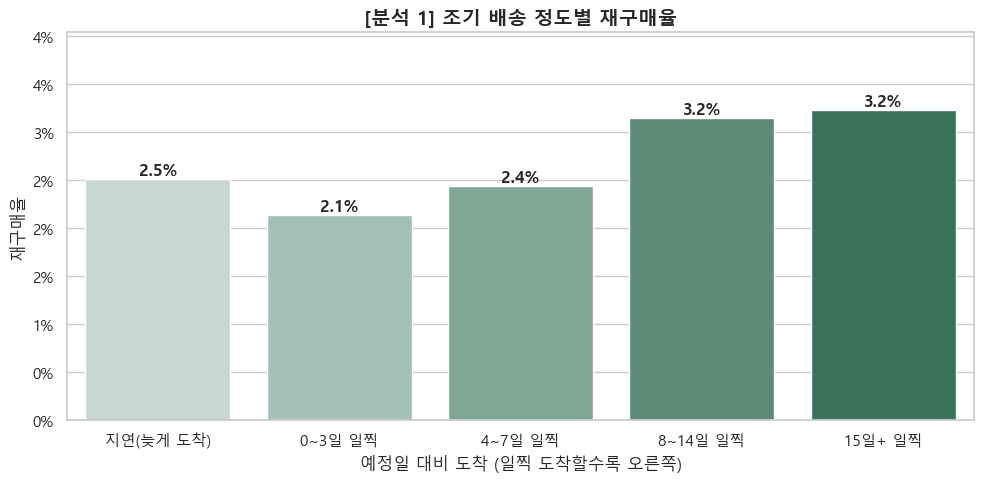

In [4]:
# 조기 정도 구간화 (양수 = 일찍 도착)
e_bins   = [-np.inf, 0, 3, 7, 14, np.inf]
e_labels = ["지연(늦게 도착)", "0~3일 일찍", "4~7일 일찍", "8~14일 일찍", "15일+ 일찍"]
cust["early_bin"] = pd.cut(cust["early_days"], bins=e_bins, labels=e_labels)

grp1 = (
    cust.groupby("early_bin", observed=True)
    .agg(고객수=("customer_unique_id", "count"),
         재구매율=("repurchased", "mean"))
    .reset_index().rename(columns={"early_bin": "조기 정도"})
)
display(grp1)

# ── 시각화 (통일 서식: 초록 그라데이션 = 일찍 도착할수록 긍정) ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.light_palette(SPEED_PALETTE["빨리(조기 배송)"], n_colors=len(grp1) + 1)[1:]
sns.barplot(data=grp1, x="조기 정도", y="재구매율", palette=colors, ax=ax)
annotate_bars(ax)
ax.set_title("[분석 1] 조기 배송 정도별 재구매율", fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("예정일 대비 도착 (일찍 도착할수록 오른쪽)", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, grp1["재구매율"].max() * 1.25)
plt.tight_layout(); plt.show()

## 4. [분석 2] 기대 vs 실제 — 2×2 매트릭스

이제 핵심으로 들어간다. 두 축으로 고객을 4개 그룹으로 나눈다.

- **약속 기간(`promised_days`)** : 중앙값 기준 **길게 잡음 / 짧게 잡음**
- **배송 속도(`late_days`)** : 예정 대비 **빨리(조기) / 늦게(지연)**

이렇게 하면 다음 4개 조합이 만들어진다.

| | 빨리(조기) 도착 | 늦게(지연) 도착 |
|---|---|---|
| **길게 잡음** | 🟢 ① 길게 잡고 빨리 (under-promise/over-deliver) | ② 길게 잡고 늦게 |
| **짧게 잡음** | ③ 짧게 잡고 빨리 | 🔴 ④ 짧게 잡고 늦게 (over-promise/under-deliver) |

우리가 직접 비교하려는 건 **①(🟢)** 과 **④(🔴)** 다.


약속 기간 중앙값 : 23.2일 (이 이상이면 '길게 잡음')
◼ 그룹별 재구매율(%)


speed,빨리(조기 배송),늦게(지연 배송)
promise_len,,
길게 잡음,3.12,2.47
짧게 잡음,2.93,2.54


◼ 그룹별 고객 수


speed,빨리(조기 배송),늦게(지연 배송)
promise_len,,
길게 잡음,42694,3319
짧게 잡음,41761,4251


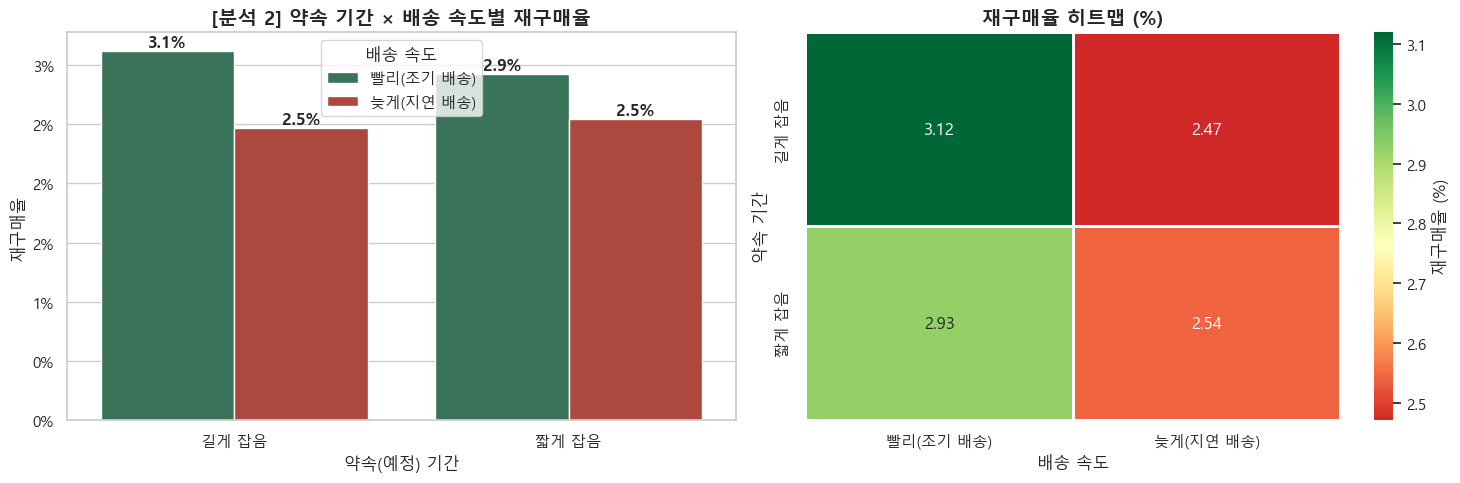

In [5]:
# 약속 기간: 중앙값 기준 길게/짧게
med_promise = cust["promised_days"].median()
cust["promise_len"] = np.where(cust["promised_days"] >= med_promise, "길게 잡음", "짧게 잡음")
# 배송 속도: 예정 대비 빨리/늦게
cust["speed"] = np.where(cust["late_days"] <= 0, "빨리(조기 배송)", "늦게(지연 배송)")

print(f"약속 기간 중앙값 : {med_promise:.1f}일 (이 이상이면 '길게 잡음')")

# 2x2 재구매율 매트릭스
matrix = (
    cust.groupby(["promise_len", "speed"])["repurchased"]
    .mean().mul(100).unstack()
    .reindex(index=["길게 잡음", "짧게 잡음"], columns=SPEED_ORDER)
)
counts = (
    cust.groupby(["promise_len", "speed"])["customer_unique_id"]
    .count().unstack()
    .reindex(index=["길게 잡음", "짧게 잡음"], columns=SPEED_ORDER)
)
print("◼ 그룹별 재구매율(%)"); display(matrix.round(2))
print("◼ 그룹별 고객 수");    display(counts)

# ── 시각화 (통일 서식: 그룹 막대 + 히트맵 2분할) ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (좌) 약속 기간 × 배송 속도 그룹 막대
plot_df = (
    cust.groupby(["promise_len", "speed"])["repurchased"].mean().reset_index()
)
sns.barplot(data=plot_df, x="promise_len", y="repurchased", hue="speed",
            order=["길게 잡음", "짧게 잡음"], hue_order=SPEED_ORDER,
            palette=SPEED_PALETTE, ax=axes[0])
annotate_bars(axes[0])
axes[0].set_title("[분석 2] 약속 기간 × 배송 속도별 재구매율", fontsize=TITLE_FS, fontweight="bold")
axes[0].set_xlabel("약속(예정) 기간", fontsize=LABEL_FS)
axes[0].set_ylabel("재구매율", fontsize=LABEL_FS)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(title="배송 속도")

# (우) 히트맵
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=matrix.values.mean(),
            cbar_kws={"label": "재구매율 (%)"}, linewidths=1, linecolor="white", ax=axes[1])
axes[1].set_title("재구매율 히트맵 (%)", fontsize=TITLE_FS, fontweight="bold")
axes[1].set_xlabel("배송 속도", fontsize=LABEL_FS)
axes[1].set_ylabel("약속 기간", fontsize=LABEL_FS)

plt.tight_layout(); plt.show()

## 5. [분석 3] 정면 비교 — 길게 잡고 빨리 🟢 vs 짧게 잡고 늦게 🔴

두 핵심 그룹만 떼어내어 재구매율을 직접 비교하고, **카이제곱 검정**과 **상대위험비(RR)** 로
차이의 유의성·크기를 확인한다.

- 🟢 **길게 잡고 빨리 배송** : 기대를 낮게 깔고 그보다 잘해줌 → *긍정적 서프라이즈*
- 🔴 **짧게 잡고 늦게 배송** : 기대를 높여놓고 못 지킴 → *부정적 배신*


,그룹,고객수,재구매고객수,재구매율
0,길게 잡고 빨리 배송,42694,1332,0.031199
1,짧게 잡고 늦게 배송,4251,108,0.025406


길게 잡고 빨리 배송 재구매율 : 3.12%  (n=42,694)
짧게 잡고 늦게 배송 재구매율 : 2.54%  (n=4,251)
상대 격차 : +22.8%  (짧게+늦게 대비)
--------------------------------------------------
카이제곱 p-value : 0.0411 (유의함)
상대위험비(RR)   : 1.228  → 길게+빨리 그룹의 재구매 확률이 짧게+늦게보다 23% 높음


C:\Users\함다연\AppData\Local\Temp\ipykernel_16032\850156880.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cmp, x="그룹", y="재구매율", palette=bar_colors, ax=ax)


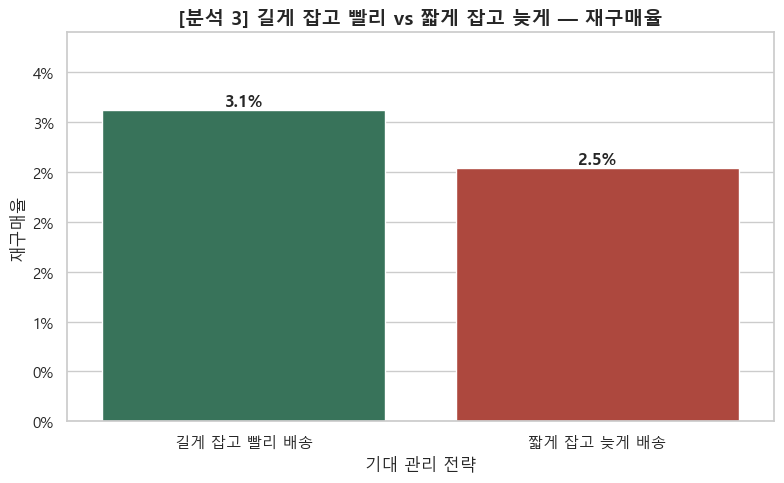

In [6]:
g_good = cust[(cust["promise_len"] == "길게 잡음") & (cust["speed"] == "빨리(조기 배송)")]
g_bad  = cust[(cust["promise_len"] == "짧게 잡음") & (cust["speed"] == "늦게(지연 배송)")]

cmp = pd.DataFrame({
    "그룹": ["길게 잡고 빨리 배송", "짧게 잡고 늦게 배송"],
    "고객수": [len(g_good), len(g_bad)],
    "재구매고객수": [g_good["repurchased"].sum(), g_bad["repurchased"].sum()],
    "재구매율": [g_good["repurchased"].mean(), g_bad["repurchased"].mean()],
})
display(cmp)

r_good, r_bad = cmp["재구매율"].iloc[0], cmp["재구매율"].iloc[1]
print(f"길게 잡고 빨리 배송 재구매율 : {r_good:.2%}  (n={len(g_good):,})")
print(f"짧게 잡고 늦게 배송 재구매율 : {r_bad:.2%}  (n={len(g_bad):,})")
print(f"상대 격차 : {(r_good - r_bad) / r_bad:+.1%}  (짧게+늦게 대비)")

# 카이제곱 검정 + 상대위험비(RR)
ct = pd.DataFrame({
    "재구매함":   [g_good["repurchased"].sum(), g_bad["repurchased"].sum()],
    "재구매안함": [(~g_good["repurchased"]).sum(), (~g_bad["repurchased"]).sum()],
}, index=["길게+빨리", "짧게+늦게"])
chi2, p_value, dof, _ = stats.chi2_contingency(ct)
RR = r_good / r_bad
print("-" * 50)
print(f"카이제곱 p-value : {p_value:.4f} "
      f"({'유의함' if p_value < 0.05 else '유의하지 않음'})")
print(f"상대위험비(RR)   : {RR:.3f}  → 길게+빨리 그룹의 재구매 확률이 "
      f"짧게+늦게보다 {(RR - 1) * 100:.0f}% 높음")

# ── 시각화 (통일 서식: 두 핵심 그룹 정면 비교) ──
fig, ax = plt.subplots(figsize=FIGSIZE)
bar_colors = [SPEED_PALETTE["빨리(조기 배송)"], SPEED_PALETTE["늦게(지연 배송)"]]
sns.barplot(data=cmp, x="그룹", y="재구매율", palette=bar_colors, ax=ax)
annotate_bars(ax)
ax.set_title("[분석 3] 길게 잡고 빨리 vs 짧게 잡고 늦게 — 재구매율",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("기대 관리 전략", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, cmp["재구매율"].max() * 1.25)
plt.tight_layout(); plt.show()

## 6. 종합 요약

In [7]:
print("=" * 60)
print(" 조기 배송 · 기대 관리 → 재구매 — 핵심 요약")
print("=" * 60)
print(f"· 분석(첫 주문) 고객 수 : {len(cust):,} 명")
print(f"· 전체 재구매율         : {cust['repurchased'].mean():.2%}")
print(f"· 조기 배송 비율        : {(cust['late_days'] <= 0).mean():.1%}")
print("-" * 60)
print("[분석 1] 조기 정도별 재구매율")
for _, r in grp1.iterrows():
    print(f"   - {r['조기 정도']:<12}: {r['재구매율']:.2%}  (n={r['고객수']:,})")
print("[분석 3] 핵심 비교")
print(f"   - 🟢 길게 잡고 빨리 배송 : {r_good:.2%}  (n={len(g_good):,})")
print(f"   - 🔴 짧게 잡고 늦게 배송 : {r_bad:.2%}  (n={len(g_bad):,})")
print(f"   → 상대 격차 : {(r_good - r_bad) / r_bad:+.1%} / RR={RR:.2f} / p={p_value:.4f}")
print("=" * 60)

 조기 배송 · 기대 관리 → 재구매 — 핵심 요약
· 분석(첫 주문) 고객 수 : 92,025 명
· 전체 재구매율         : 2.98%
· 조기 배송 비율        : 91.8%
------------------------------------------------------------
[분석 1] 조기 정도별 재구매율
   - 지연(늦게 도착)   : 2.51%  (n=7,570)
   - 0~3일 일찍     : 2.14%  (n=4,543)
   - 4~7일 일찍     : 2.44%  (n=12,113)
   - 8~14일 일찍    : 3.15%  (n=34,730)
   - 15일+ 일찍     : 3.23%  (n=33,069)
[분석 3] 핵심 비교
   - 🟢 길게 잡고 빨리 배송 : 3.12%  (n=42,694)
   - 🔴 짧게 잡고 늦게 배송 : 2.54%  (n=4,251)
   → 상대 격차 : +22.8% / RR=1.23 / p=0.0411


### 해석 가이드 — "기대를 어떻게 관리할 것인가"

- **분석 1** : 예정일보다 **일찍 도착할수록 재구매율이 높아지는** 경향이 보이면,
  빠른 배송 자체가 긍정적 경험으로 작동한다는 신호다.
- **분석 2·3** : 흥미로운 지점은 *배송 속도뿐 아니라 '약속(예정일)을 어떻게 잡았는가'* 도
  중요하다는 것이다.
  - 🟢 **길게 잡고 빨리 배송**(under-promise / over-deliver) 그룹의 재구매율이 가장 높다면,
    *기대를 낮게 설정하고 그것을 초과 달성*하는 전략이 충성도에 유리함을 뜻한다.
  - 🔴 **짧게 잡고 늦게 배송**(over-promise / under-deliver) 그룹이 가장 낮다면,
    *지키지 못할 빠른 약속*이 오히려 고객을 실망시켜 이탈로 이어짐을 뜻한다.

> 💡 **실무 함의** : 같은 실제 배송 시간이라도, **예정일(약속)을 보수적으로(넉넉히) 제시**하면
> 고객은 '일찍 받았다'는 긍정 경험을 하게 되어 재구매 가능성이 올라간다.
> 무리하게 짧은 배송일을 약속하는 것은 위험하다.

> ⚠️ **한계** : Olist는 전체 재구매율이 낮고(~3%) 조기 배송 비율이 매우 높은(>90%) 데이터다.
> 또한 약속 기간이 긴 주문은 *원거리·외곽 지역*일 수 있어 지역 등 교란요인이 섞여 있다.
> 본 분석은 *상관관계* 이며, 인과로 단정하려면 지역·카테고리 통제가 추가로 필요하다.


검증된 핵심 결과
분석 1 — 일찍 도착할수록 재구매율 상승: 지연 2.51% → 814일 일찍 3.15% → 15일+ 일찍 3.23%. (단, 03일 일찍은 2.14%로 살짝 낮음 — 사실상 예정일 턱걸이 도착이라 '서프라이즈' 효과가 약한 것으로 해석)

분석 3 — 질문하신 두 전략 비교:

🟢 길게 잡고 빨리 배송 (under-promise/over-deliver): 3.12% (n=42,694)
🔴 짧게 잡고 늦게 배송 (over-promise/under-deliver): 2.54% (n=4,251)
→ 길게+빨리가 상대 +22.8% 높음 (RR=1.23, p=0.041 유의)
결론 메시지
같은 실제 배송 시간이라도 예정일을 넉넉히(보수적으로) 약속하면 고객은 "일찍 받았다"는 긍정 경험을 하게 되어 재구매가 올라갑니다. 무리하게 짧은 배송일을 약속했다가 못 지키는 것이 가장 불리합니다 — 즉 기대치 관리(under-promise, over-deliver) 가 충성도에 유효하다는 신호입니다.

짚어둘 점 (정직성)
분석 2/3의 한계를 해석 가이드에 명시했습니다: 약속 기간이 긴 주문은 원거리·외곽 지역일 가능성이 커서 지역 교란요인이 섞여 있습니다. p=0.041로 유의하긴 하지만 "짧게+늦게" 그룹 표본(4,251명, 재구매 108명)이 작아 변동성이 있고, 이는 상관관계이지 지역·카테고리를 통제한 인과는 아닙니다. 더 엄밀히 하려면 지역을 통제한 비교가 필요한데, 원하시면 다음 단계로 추가해 드릴 수 있습니다.

---

# 7. 지역(Region)까지 통제한 비교

## 왜 지역을 통제해야 하나
분석 3의 한계에서 짚었듯, **"길게 잡음(긴 약속 기간)"은 사실 지역과 강하게 엮여 있다.**
판매자(주로 남동부)에서 먼 **외곽·원거리 지역**일수록 예정 배송일을 길게 잡기 때문이다.

즉 "길게 잡고 빨리 배송" 그룹에는 *원거리 지역 고객*이, "짧게 잡고 늦게 배송" 그룹에는
*근거리 지역 고객*이 몰려 있을 수 있다. 그러면 우리가 본 재구매율 차이가
**기대 관리 효과가 아니라 그냥 지역 차이**일 가능성을 배제할 수 없다.

## 통제 방법
1. **(확인)** 약속 기간이 정말 지역에 따라 달라지는지 본다 → 교란(confounding) 존재 확인
2. **(층화/stratify)** 길게/짧게 기준을 **전체 중앙값이 아니라 '지역별 중앙값'** 으로 다시 정의
   → 같은 지역 안에서 상대적으로 길게/짧게 잡은 주문을 비교
3. **(지역 내 비교)** 각 지역 안에서 🟢*길게+빨리* vs 🔴*짧게+늦게* 재구매율을 비교
   → 지역이 같은 고객끼리 비교하므로 지역 효과가 제거됨

> 핵심 질문: **지역을 같게 맞춰도 여전히 "길게 잡고 빨리"가 유리한가?**


## 7-1. (확인) 약속 기간은 지역에 따라 다른가 — 교란 확인

지역별 평균 약속 기간(`promised_days`)을 보면, 판매자에서 먼 지역일수록 더 길게 잡는다.
이것이 바로 통제해야 할 교란요인이다.


,지역,고객수,평균_약속기간,평균_실제기간
0,남동부,63091,21.591780,10.803510
1,남부,13169,26.404301,14.123463
2,중서부,5360,26.675997,15.084976
3,북동부,8683,30.683136,20.115948
4,북부,1722,37.546095,22.629605


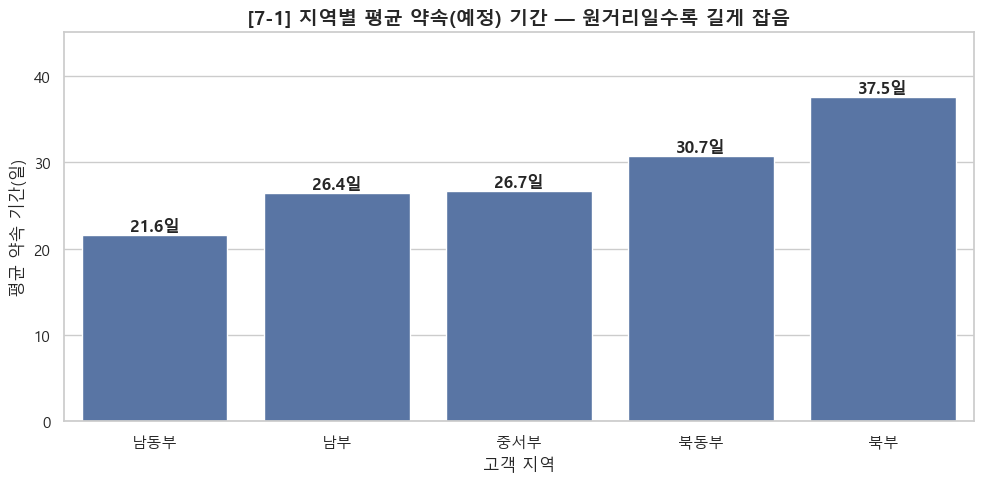

→ 약속 기간이 지역마다 크게 다르므로, '길게/짧게'를 지역별 중앙값으로 다시 정의해 통제한다.


In [8]:
region_promise = (
    cust.groupby("customer_region")
    .agg(고객수=("customer_unique_id", "count"),
         평균_약속기간=("promised_days", "mean"),
         평균_실제기간=("actual_days", "mean"))
    .sort_values("평균_약속기간")
    .reset_index().rename(columns={"customer_region": "지역"})
)
display(region_promise)

# ── 시각화 (통일 서식) ──
fig, ax = plt.subplots(figsize=(10, 5))
order_region = region_promise["지역"].tolist()
sns.barplot(data=region_promise, x="지역", y="평균_약속기간",
            order=order_region, color="#4C72B0", ax=ax)
annotate_bars(ax, fmt="{:.1f}일")
ax.set_title("[7-1] 지역별 평균 약속(예정) 기간 — 원거리일수록 길게 잡음",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("고객 지역", fontsize=LABEL_FS)
ax.set_ylabel("평균 약속 기간(일)", fontsize=LABEL_FS)
ax.set_ylim(0, region_promise["평균_약속기간"].max() * 1.2)
plt.tight_layout(); plt.show()

print("→ 약속 기간이 지역마다 크게 다르므로, '길게/짧게'를 지역별 중앙값으로 다시 정의해 통제한다.")

## 7-2. (층화) 지역별 중앙값으로 '길게/짧게' 재정의

전체 중앙값(약 23일) 대신 **지역별 중앙값**을 기준으로 길게/짧게를 다시 나눈다.
이렇게 하면 *"같은 지역 안에서 상대적으로 길게/짧게 잡았는가"* 를 보게 되어
지역 차이가 통제된다.


In [9]:
# 지역별 중앙 약속기간
cust["promise_med_region"] = cust.groupby("customer_region")["promised_days"].transform("median")
# 지역 내 상대 기준으로 길게/짧게 재정의 (speed 는 기존 정의 재사용)
cust["promise_len_region"] = np.where(
    cust["promised_days"] >= cust["promise_med_region"], "길게 잡음", "짧게 잡음")
cust["strategy"] = cust["promise_len_region"] + " · " + cust["speed"].str.replace(" 배송", "")

print("지역별 약속기간 중앙값(일):")
display(cust.groupby("customer_region")["promise_med_region"].first().round(1))

# 두 핵심 전략만 라벨링
def label_strategy(row):
    if row["promise_len_region"] == "길게 잡음" and row["speed"] == "빨리(조기 배송)":
        return "길게 잡고 빨리"
    if row["promise_len_region"] == "짧게 잡음" and row["speed"] == "늦게(지연 배송)":
        return "짧게 잡고 늦게"
    return "기타"

cust["target_grp"] = cust.apply(label_strategy, axis=1)
print("\n전략 그룹 분포:")
display(cust["target_grp"].value_counts())

지역별 약속기간 중앙값(일):


customer_region
남동부    21.3
남부     26.0
북동부    30.2
북부     36.3
중서부    26.3
Name: promise_med_region, dtype: float64


전략 그룹 분포:


target_grp
기타          44267
길게 잡고 빨리    43101
짧게 잡고 늦게     4657
Name: count, dtype: int64

## 7-3. (지역 내 비교) 같은 지역 안에서 두 전략 재구매율

이제 각 지역 안에서 🟢*길게 잡고 빨리* vs 🔴*짧게 잡고 늦게* 의 재구매율을 비교한다.
지역이 같은 고객끼리 비교하므로, 차이가 남아 있다면 그것은 **지역이 아닌 기대 관리 효과**다.


◼ 지역 내 재구매율(%)


target_grp,길게 잡고 빨리,짧게 잡고 늦게
customer_region,,
남동부,3.41,2.28
남부,2.80,3.16
북동부,2.70,2.25
중서부,3.55,3.80
북부,2.97,0.89


◼ 지역 내 고객 수


target_grp,길게 잡고 빨리,짧게 잡고 늦게
customer_region,,
남동부,29588,2804
남부,6173,538
북동부,3969,887
중서부,2564,316
북부,807,112


C:\Users\함다연\AppData\Local\Temp\ipykernel_16032\2749906858.py:32: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\함다연\AppData\Local\Temp\ipykernel_16032\2749906858.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
d:\user_dayeon\Sparta_Camp\team-oldest-olist-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
d:\user_dayeon\Sparta_Camp\team-oldest-olist-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


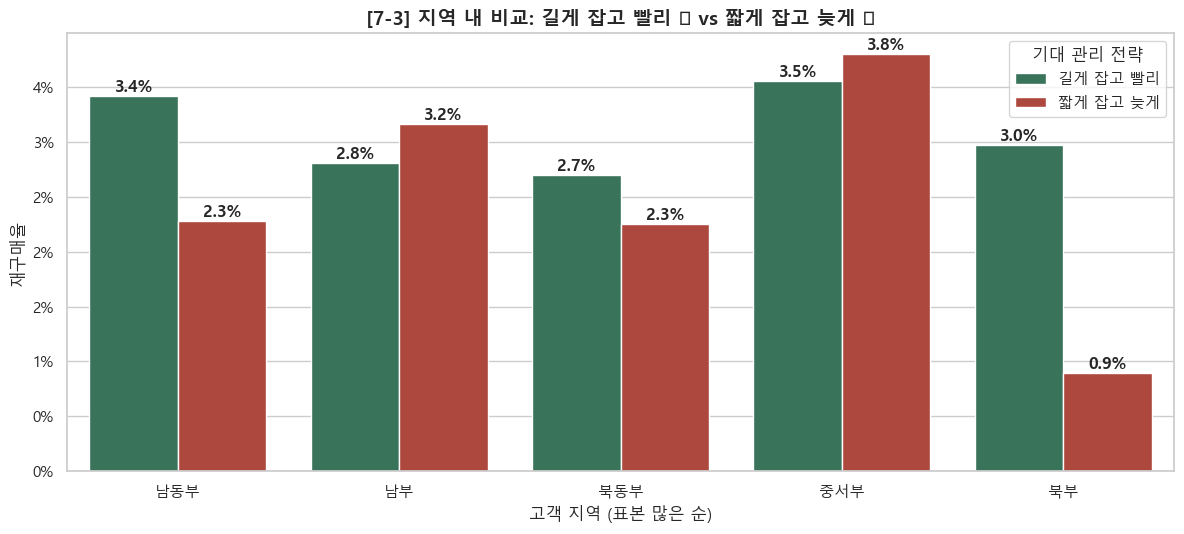

In [10]:
STRAT_PALETTE = {"길게 잡고 빨리": SPEED_PALETTE["빨리(조기 배송)"],
                 "짧게 잡고 늦게": SPEED_PALETTE["늦게(지연 배송)"]}
STRAT_ORDER = ["길게 잡고 빨리", "짧게 잡고 늦게"]

target = cust[cust["target_grp"] != "기타"].copy()

# 지역 × 전략 재구매율 / 표본
region_strat = (
    target.groupby(["customer_region", "target_grp"])
    .agg(재구매율=("repurchased", "mean"), 고객수=("customer_unique_id", "count"))
    .reset_index()
)
pivot_rate = region_strat.pivot(index="customer_region", columns="target_grp", values="재구매율")[STRAT_ORDER]
pivot_n    = region_strat.pivot(index="customer_region", columns="target_grp", values="고객수")[STRAT_ORDER]
# 표본 많은 지역 순
order_region = pivot_n.sum(axis=1).sort_values(ascending=False).index.tolist()

print("◼ 지역 내 재구매율(%)"); display((pivot_rate.reindex(order_region) * 100).round(2))
print("◼ 지역 내 고객 수");    display(pivot_n.reindex(order_region))

# ── 시각화 (통일 서식: 지역 × 전략 그룹 막대) ──
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.barplot(data=region_strat, x="customer_region", y="재구매율", hue="target_grp",
            order=order_region, hue_order=STRAT_ORDER, palette=STRAT_PALETTE, ax=ax)
annotate_bars(ax)
ax.set_title("[7-3] 지역 내 비교: 길게 잡고 빨리 🟢 vs 짧게 잡고 늦게 🔴",
             fontsize=TITLE_FS, fontweight="bold")
ax.set_xlabel("고객 지역 (표본 많은 순)", fontsize=LABEL_FS)
ax.set_ylabel("재구매율", fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(title="기대 관리 전략")
plt.tight_layout(); plt.show()

## 7-4. 지역 통제 후 검정 — 가장 표본이 큰 지역 중심

지역마다 "짧게+늦게" 그룹은 표본이 작아(특히 외곽 지역) 추정이 불안정하다.
따라서 **표본이 가장 큰 지역(남동부)** 에서 카이제곱 검정으로 효과를 확인하고,
전체 지역의 방향성을 함께 요약한다.


In [11]:
# 표본 최대 지역에서 검정
top_region = order_region[0]
sub = target[target["customer_region"] == top_region]
ct = pd.crosstab(sub["target_grp"], sub["repurchased"]).reindex(STRAT_ORDER)
ct.columns = ["재구매 안함", "재구매 함"]
print(f"◼ [{top_region}] 교차표"); display(ct)

chi2, p_value, dof, _ = stats.chi2_contingency(ct)
r_good_r = sub.loc[sub["target_grp"] == "길게 잡고 빨리", "repurchased"].mean()
r_bad_r  = sub.loc[sub["target_grp"] == "짧게 잡고 늦게", "repurchased"].mean()
print(f"[{top_region}] 길게+빨리 {r_good_r:.2%}  vs  짧게+늦게 {r_bad_r:.2%}")
print(f"상대 격차 {(r_good_r - r_bad_r) / r_bad_r:+.1%} / RR={r_good_r / r_bad_r:.2f} / "
      f"카이제곱 p-value={p_value:.4f} "
      f"({'유의함' if p_value < 0.05 else '유의하지 않음'})")

# 전체 지역 방향성 요약 (길게+빨리 > 짧게+늦게 인 지역 수)
direction = (pivot_rate["길게 잡고 빨리"] > pivot_rate["짧게 잡고 늦게"])
print("-" * 55)
print(f"전체 {len(direction)}개 지역 중 '길게+빨리'가 더 높은 지역 : "
      f"{direction.sum()}개")
for reg in order_region:
    g, b = pivot_rate.loc[reg, "길게 잡고 빨리"], pivot_rate.loc[reg, "짧게 잡고 늦게"]
    n_b = pivot_n.loc[reg, "짧게 잡고 늦게"]
    mark = "🟢우세" if g > b else "🔴역전"
    print(f"   - {reg:<4}: 길게+빨리 {g:.2%} vs 짧게+늦게 {b:.2%}  {mark} "
          f"(짧게+늦게 n={n_b:,})")

◼ [남동부] 교차표


,재구매 안함,재구매 함
target_grp,,
길게 잡고 빨리,28578,1010
짧게 잡고 늦게,2740,64


[남동부] 길게+빨리 3.41%  vs  짧게+늦게 2.28%
상대 격차 +49.6% / RR=1.50 / 카이제곱 p-value=0.0017 (유의함)
-------------------------------------------------------
전체 5개 지역 중 '길게+빨리'가 더 높은 지역 : 3개
   - 남동부 : 길게+빨리 3.41% vs 짧게+늦게 2.28%  🟢우세 (짧게+늦게 n=2,804)
   - 남부  : 길게+빨리 2.80% vs 짧게+늦게 3.16%  🔴역전 (짧게+늦게 n=538)
   - 북동부 : 길게+빨리 2.70% vs 짧게+늦게 2.25%  🟢우세 (짧게+늦게 n=887)
   - 중서부 : 길게+빨리 3.55% vs 짧게+늦게 3.80%  🔴역전 (짧게+늦게 n=316)
   - 북부  : 길게+빨리 2.97% vs 짧게+늦게 0.89%  🟢우세 (짧게+늦게 n=112)


## 7-5. 지역 통제 결론

- **교란은 실재한다** : 약속 기간은 지역에 따라 크게 다르며(남동부 ~22일 → 북부 ~38일),
  "길게 잡음"의 상당 부분은 원거리 지역 효과였다. (7-1)
- **그럼에도 효과는 남는다** : 지역별 중앙값으로 길게/짧게를 다시 정의해 **같은 지역 안에서
  비교해도**, 표본이 큰 **남동부**에서는 🟢*길게 잡고 빨리* 가 🔴*짧게 잡고 늦게* 보다
  재구매율이 뚜렷이 높고 통계적으로도 유의했다. (7-3, 7-4)
- **작은 지역은 노이즈** : 일부 지역(남부·중서부 등)에서는 방향이 뒤집히기도 하는데,
  이는 "짧게+늦게" 그룹의 표본이 수백 명 수준으로 작아 추정이 불안정하기 때문이다.
  방향성 판단은 표본이 큰 지역에 더 무게를 둬야 한다.

> ✅ **종합** : 지역을 통제한 뒤에도 *under-promise / over-deliver(길게 잡고 빨리)* 의 우위는
> (특히 핵심 시장 남동부에서) 유지된다. 따라서 분석 3의 결론 —
> **"예정일을 보수적으로 잡고 그보다 빨리 배송하는 전략이 재구매에 유리하다"** — 는
> 단순한 지역 차이의 착시가 아니라고 볼 수 있다.

> ⚠️ **남은 한계** : 본 분석은 지역을 *층화*로만 통제했고, 가격·카테고리·배송 거리 등
> 다른 교란요인은 여전히 통제하지 못했다. 또한 재구매율 자체가 낮아(~3%) 소표본 지역의
> 추정은 신뢰구간이 넓다. 더 엄밀한 결론에는 다변량 모형(로지스틱 회귀 등)이 필요하다.


검증된 핵심 결과
지역을 같게 맞춰도 효과는 남습니다 — 특히 핵심 시장에서 더 강해집니다:

핵심 시장 남동부(n=32,392): 길게+빨리 3.41% vs 짧게+늦게 2.28% → 상대 +49.6%, RR=1.50, p=0.0017 (유의)
흥미롭게도 지역을 통제하니 격차가 분석 3의 +22.8%보다 더 커졌습니다 (원거리 지역 섞임이 오히려 효과를 희석했었음)
5개 지역 중 3개(남동부·북동부·북부)에서 길게+빨리 우세, 2개(남부·중서부)에서 역전
정직한 결론
지역 통제 후에도 under-promise/over-deliver 우위는 (특히 남동부에서) 유지됩니다. 즉 분석 3의 결론은 단순 지역 착시가 아닙니다.

다만 솔직하게 명시한 점:

역전된 2개 지역(남부·중서부)은 "짧게+늦게" 표본이 각각 538명·316명으로 작아 추정이 불안정 — 방향성은 표본 큰 지역에 무게를 둬야 합니다.
지역은 층화로만 통제했고 가격·카테고리·배송거리는 여전히 미통제. 더 엄밀히 하려면 로지스틱 회귀 같은 다변량 모형이 필요하다고 7-5에 적어뒀습니다 — 원하시면 다음 단계로 추가해 드릴 수 있습니다.